# Fourier filtering

Fourier transforms can be used to filter signals, e.g. we may be interested in removing low- or high-frequencies from a signal.


This is particularly useful for image analysis, and there is a series of algorithms dedicated to image filtering.


- **Low-pass filtering:** filters out the high (spatial) frequencies, i.e. enhance large-scale structure.


- **High-pass filtering:** filters out the low (spatial) frequencies, i.e. enhance small-scale structure.


## Example:

(a) Generate 3 sine waves with frequencies $1\rm Hz$, $5 Hz$, and $8 Hz$, amplitudes $4$, $2$ and $0.25$, and phase all zeros.

(b) Plot this $3$ sine waves together with a sampling rate $128 Hz$.

(c) Calculate the FFT of the resulting signal and return the Fourier amplitudes and phases.

(d) Filter out the highest and lowest frequency components from the signal and return the iFFT of it.

(e) Compare it to the iFFT of the original signal.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [2]:
def sine_wave(amp, freq, t):
    # amp  = amplitude
    # freq = frequency
    # t    = time_axis
    
    return amp*np.sin(2*np.pi*freq*t) #omega = 2*np.pi*freq

In [3]:
# sampling rate
s_rate = 128 #Hz

# sampling spacing
s_interval = 1.0/s_rate

# t_axis
t = np.arange(0, 1, s_interval)

# y axis
signal_3 = sine_wave(4,1,t) + sine_wave(2,5,t) + sine_wave(0.25,8,t)

### Plotting:

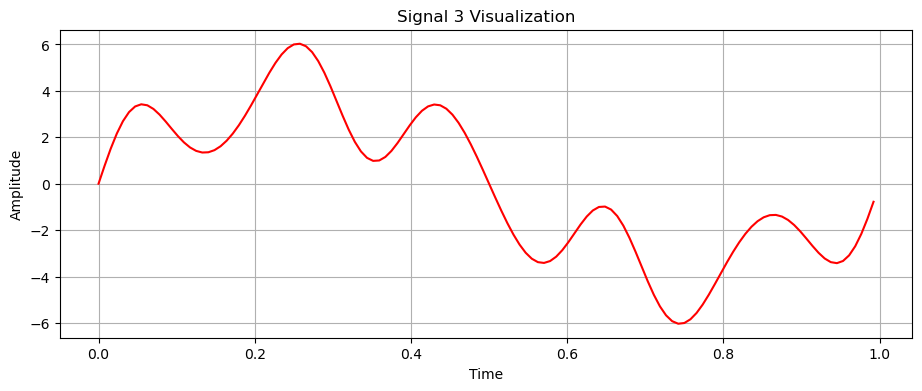

In [4]:
plt.figure(figsize = (11, 4))
plt.plot(t, signal_3, 'r')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.title('Signal 3 Visualization')
plt.grid(True)
plt.show()

## Fourier transforms:

In [5]:
# Fourier transform:

fourier_s3 = np.fft.fft(signal_3)

# Let's make some copies of the FFT to not rewrite the Fourier transform:

filtered_s3_1 = fourier_s3.copy()
filtered_s3_2 = fourier_s3.copy()
filtered_s3_3 = fourier_s3.copy()
filtered_s3_4 = fourier_s3.copy()

# Calculate frequencies:

freqs_s3 = np.fft.fftfreq(signal_3.size, s_interval)

# Normalized real values (amplitudes) of the Fourier transform:
# The FFT returns complex numbers, so we need to take the absolute value
# and divide by the number of samples to get the amplitude spectrum.

ampli_s3 = np.abs(fourier_s3)/(signal_3.size//2)

# Fourier Phases

phase_s3 = np.arctan2(fourier_s3.imag, fourier_s3.real)

## Fourier plots:

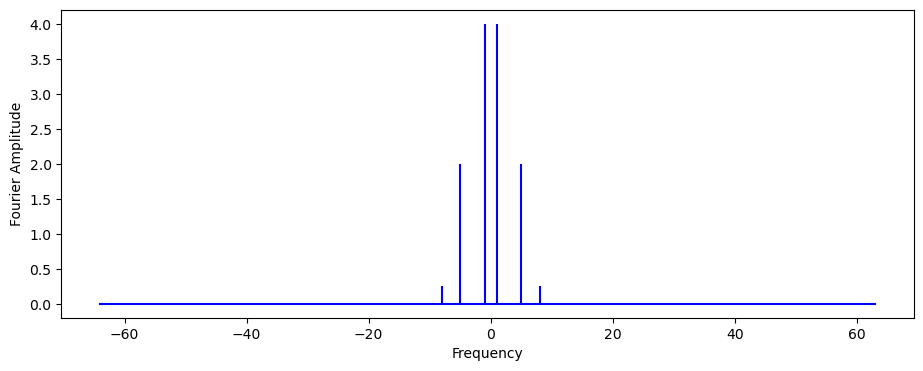

In [6]:
#Frequency domain visualization

plt.figure(figsize = (11, 4))
plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency')
plt.ylabel('Fourier Amplitude')

plt.show()

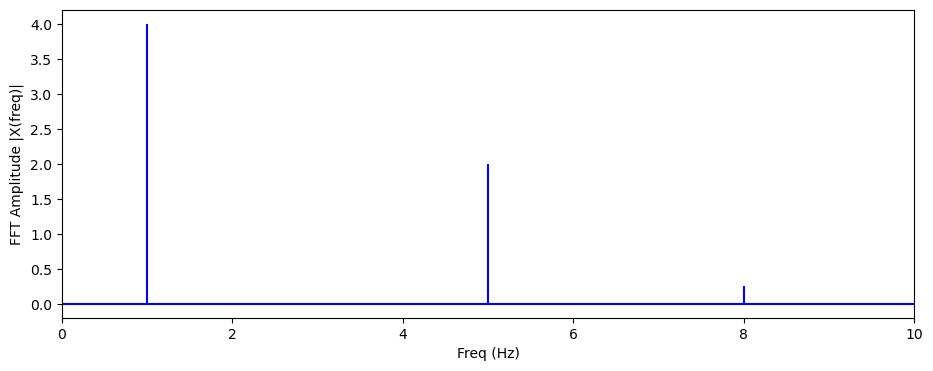

In [7]:
# We can ignore the negative frequencies, as they are just a mirror image of the positive ones.

plt.figure(figsize = (11, 4))
plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0,10)
plt.show()

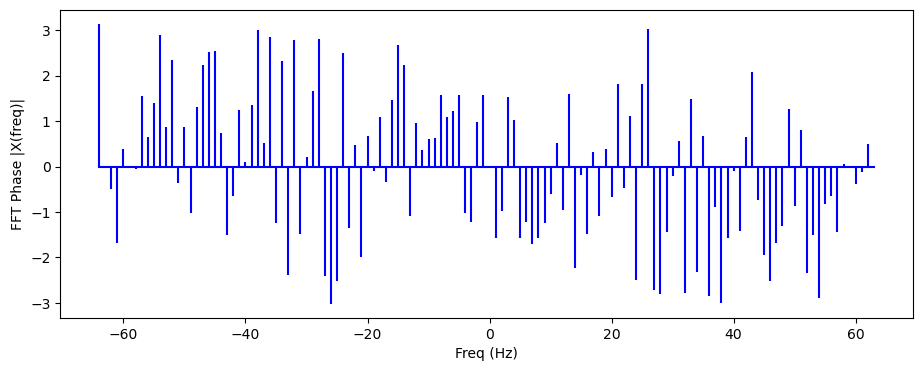

In [8]:
#Plot of Fourier Phase

plt.figure(figsize = (11, 4))
plt.stem(freqs_s3, phase_s3, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Phase |X(freq)|')
#plt.xlim(0,10)
plt.show()

Yikes, it's really messy. We won't be using these.

## Inverse Fourier transform:

In [9]:
invF_s3 = np.fft.ifft(fourier_s3)

#print(invF_s3)

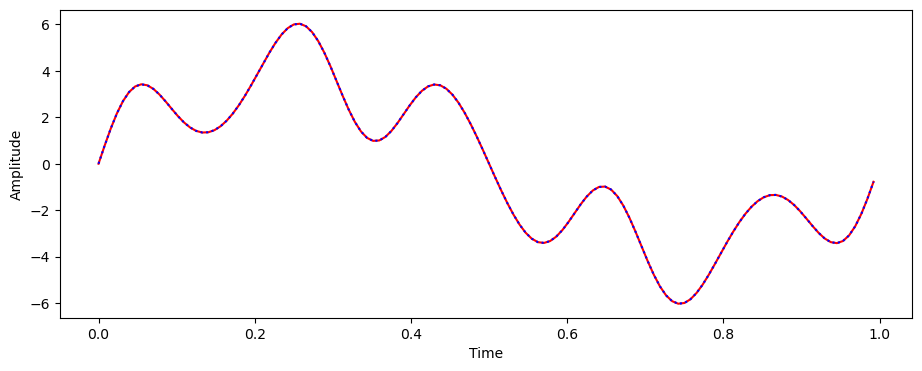

In [10]:
#We're back in the time domain

plt.figure(figsize = (11, 4))
# Original signal:
plt.plot(t, signal_3, 'r')
# iFFT signal:
plt.plot(t, invF_s3.real, 'b', linestyle = ":")
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.show()

# High-pass Filter:

We assign zeros to the FFT amplitudes where the absolute frequencies are smaller than the high cut-off frequency.
We remove the large scale structure associated with low frequencies.

## Example:

Filter out the lowest frequency (1Hz).


In [11]:
# Cut-off frequency
h_cutoff = 4  #Hz
h_cutoff_2 = 6  #Hz


# Filtered Fourier signal. This is where we use the generated copies of the FFT. Use indexing
filtered_s3_1[np.abs(freqs_s3) < h_cutoff ] = 0
filtered_s3_2[np.abs(freqs_s3) < h_cutoff_2 ] = 0

# Norm of FILTERED Fourier transform

ampli_filtered_s3_1 = np.abs(filtered_s3_1)/(signal_3.size//2)
ampli_filtered_s3_2 = np.abs(filtered_s3_2)/(signal_3.size//2)

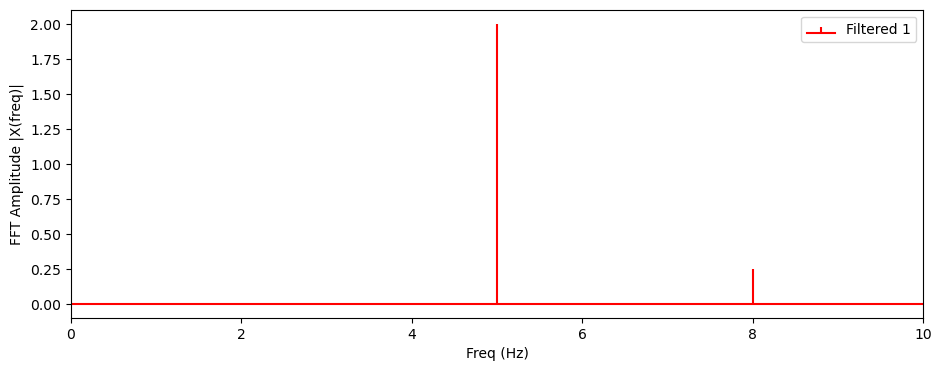

In [12]:
#First cut off frequency plotting 

plt.figure(figsize = (11, 4))
#plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b", label="Original")
plt.stem(freqs_s3, ampli_filtered_s3_1, 'r', markerfmt=" ", basefmt="-r", label="Filtered 1")
#plt.stem(freqs_s3, ampli_filtered_s3_2, 'y', markerfmt=" ", basefmt="-y", label="Filtered 2")
plt.legend()
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0,10)
plt.show()

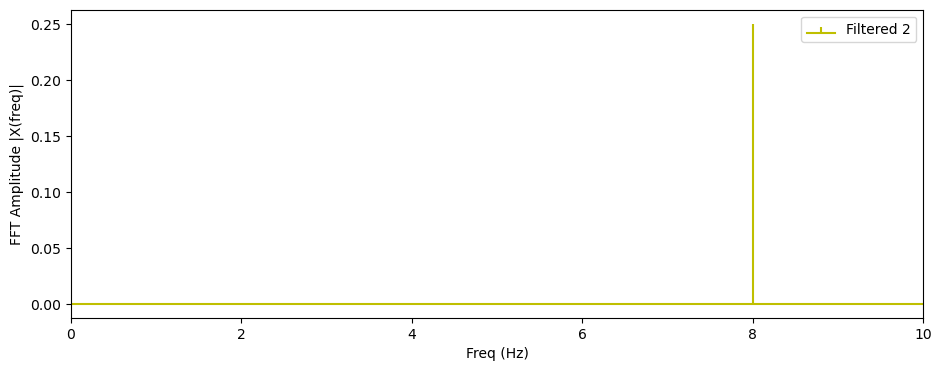

In [13]:
#Second cut off frequency plotting

plt.figure(figsize = (11, 4))
#plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b")
#plt.stem(freqs_s3, ampli_filtered_s3_1, 'r', markerfmt=" ", basefmt="-r")
plt.stem(freqs_s3, ampli_filtered_s3_2, 'y', markerfmt=" ", basefmt="-y", label="Filtered 2")
plt.legend()
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0,10)
plt.show()

### Inverse Fourier transform of filtered signal:

In [14]:
inv_filtered_s3_1 = np.fft.ifft(filtered_s3_1)

inv_filtered_s3_2 = np.fft.ifft(filtered_s3_2)

### Plotting the filtered signal back in the time domain:

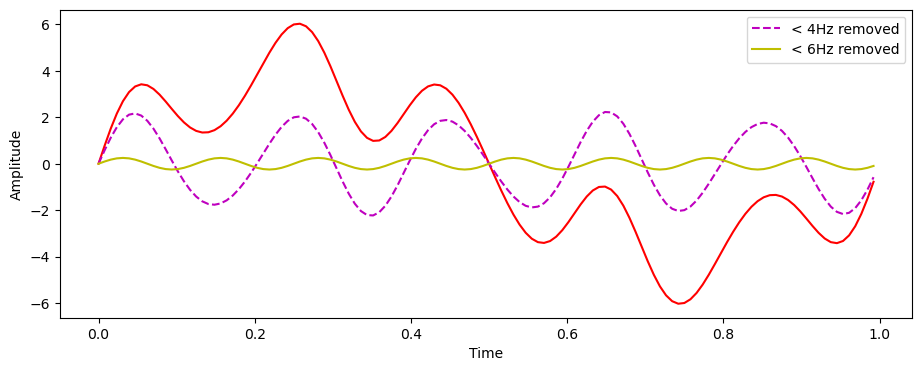

In [15]:
plt.figure(figsize = (11, 4))
# Original signal:
plt.plot(t, signal_3, 'r')

# iFFT signal:
#plt.plot(t, invF_s3.real, 'b', linestyle = ":")

# iFFT filtered signal:
plt.plot(t, inv_filtered_s3_1.real, 'm', linestyle = "--", label = "< 4Hz removed")
plt.plot(t, inv_filtered_s3_2.real, 'y', linestyle = "-", label = "< 6Hz removed")

# Higher frequency signals:
#plt.plot(t, sine_wave(2,5,t) + sine_wave(0.25,8,t), 'g', linestyle = "-.") #this should coincide to the first filtered signal
#plt.plot(t, sine_wave(0.25,8,t), 'g', linestyle = "-.") #this should coincide to the second filtered signal

plt.legend()
plt.xlabel('Time')
plt.ylabel('Amplitude')


plt.show()

We see that the large-scale structure is not matched anymore.

# Low-pass Filter:

We assign zeros to the FFT amplitudes where the absolute frequencies are larger than the low cut-off frequency. We remove the details (small scale structure) of the signal.


In [16]:
l_cutoff_3 = 7.
l_cutoff_3_2 = 3.

#Filtering the Fourier signal
filtered_s3_3[np.abs(freqs_s3) > l_cutoff_3] = 0
filtered_s3_4[np.abs(freqs_s3) > l_cutoff_3_2] = 0

#IFT of filtered signals
inv_filter_s3_3 = np.fft.ifft(filtered_s3_3)
inv_filter_s3_4 = np.fft.ifft(filtered_s3_4)

# Norm of FILTERED Fourier transform
ampli_filtered_s3_3 = np.abs(filtered_s3_3)/(signal_3.size//2)
ampli_filtered_s3_4 = np.abs(filtered_s3_4)/(signal_3.size//2)

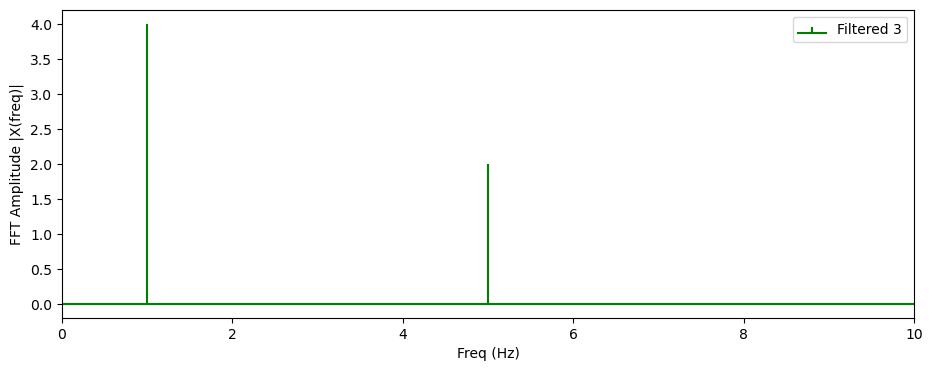

In [17]:
plt.figure(figsize = (11, 4))
#plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b", label="Original")
plt.stem(freqs_s3, ampli_filtered_s3_3, 'g', markerfmt=" ", basefmt="-g", label="Filtered 3")
#plt.stem(freqs_s3, ampli_filtered_s3_4, 'y', markerfmt=" ", basefmt="-y", label="Filtered 4")
plt.legend()
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0,10)
plt.show()

We've removed the highest frequency.

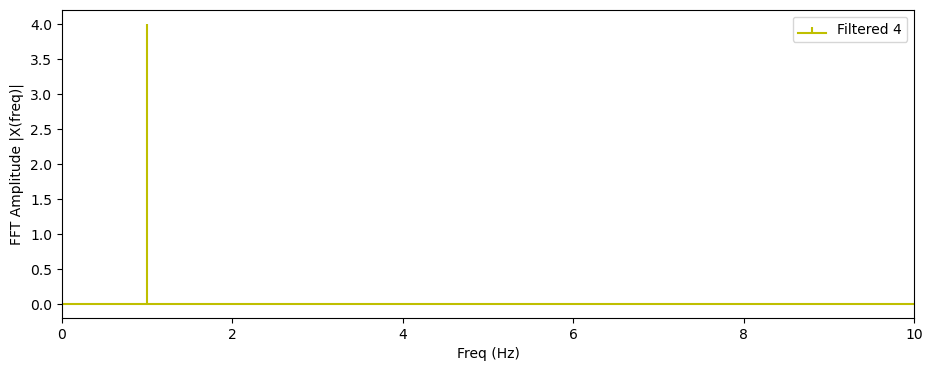

In [18]:
plt.figure(figsize = (11, 4))
#plt.stem(freqs_s3, ampli_s3, 'b', markerfmt=" ", basefmt="-b", label="Original")
#plt.stem(freqs_s3, ampli_filtered_s3_3, 'g', markerfmt=" ", basefmt="-g", label="Filtered 3")
plt.stem(freqs_s3, ampli_filtered_s3_4, 'y', markerfmt=" ", basefmt="-y", label="Filtered 4")
plt.legend()
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0,10)
plt.show()

We've removed the two highest frequencies.

### Plotting the filtered signal back in the time domain:

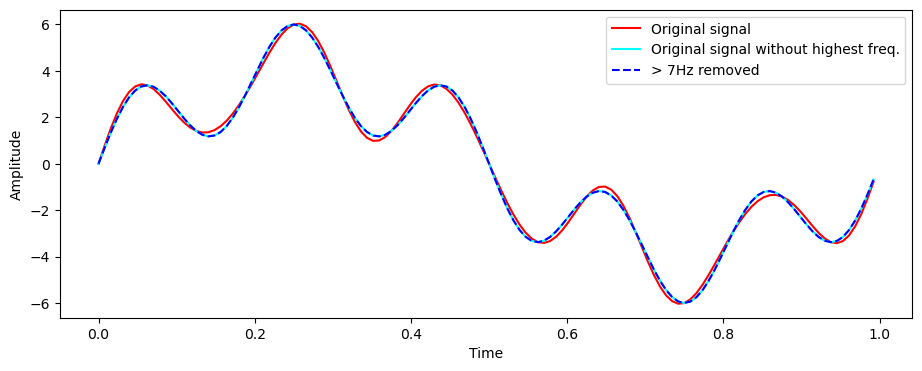

In [19]:
plt.figure(figsize = (11, 4))
plt.plot(t, signal_3, 'r', label = "Original signal")
#plt.plot(t, invF_s3.real, 'b', linestyle = ":")
plt.plot(t, sine_wave(4,1,t) + sine_wave(2,5,t), 'cyan', label = "Original signal without highest freq.") #this should coincide to the first filtered signal
plt.plot(t, inv_filter_s3_3.real, 'blue', linestyle = "--", label = "> 7Hz removed")

plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.legend()
plt.show()

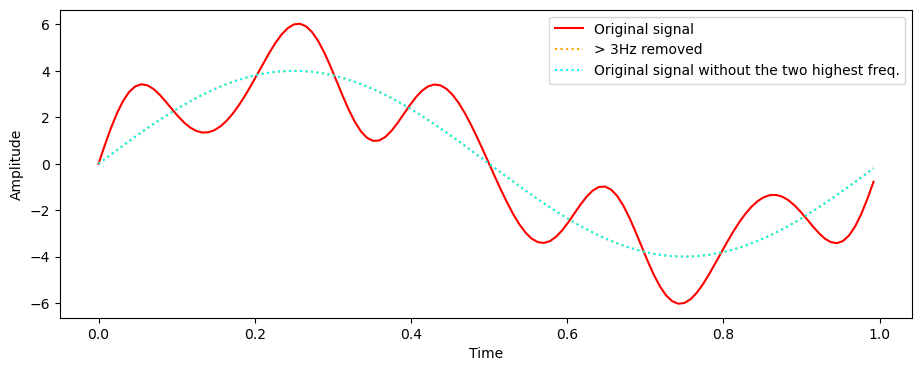

In [20]:
plt.figure(figsize = (11, 4))
plt.plot(t, signal_3, 'r', label = "Original signal")
#plt.plot(t, invF_s3.real, 'b', linestyle = ":")
plt.plot(t, inv_filter_s3_4.real, 'orange', linestyle = ":", label = "> 3Hz removed")

#We compare the filtered signal with the original signal without the removed frequencies.
plt.plot(t, sine_wave(4,1,t), 'cyan', linestyle = ":", label = "Original signal without the two highest freq.")
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.legend()
plt.show()